# Shade Index Evaluation

**Claim:** VLM `pedestrian_shade_score` agrees with human shade judgment on a hand-labeled sample of streetscape images.

**Ground truth:** Hand labels on 1–5 scale (normalized to 0–1), single rater, afternoon pedestrian context.

**Limitations:** N≈30 real images, one Singapore corridor, static snapshots, no solar geometry modelling. Tier A uses single-run scores from `eval/data/scores.csv`; Tier B checks stability on a 10-image subset. Optional synthetic gap-fill images are excluded from Tier A headline metrics.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display

sys.path.insert(0, str(Path.cwd()))
print('notebook cwd', Path.cwd())

from eval.metrics import (
    HIGH_VARIANCE_RANGE,
    MISMATCH_THRESHOLD,
    build_eval_frame,
    compute_method_metrics,
    filter_real_images,
    flag_mismatches,
    load_eval_metadata,
    merge_run_stability,
    per_image_run_stats,
    resolve_image_path,
    stability_summary,
    summarize_mismatches_by_scene_category,
)
from eval.paths import EVAL_SCORES_CSV, HUMAN_LABELS_CSV, RUN_VARIANCE_CSV

labels = pd.read_csv(HUMAN_LABELS_CSV)
metadata = load_eval_metadata()

if EVAL_SCORES_CSV.exists():
    scores = pd.read_csv(EVAL_SCORES_CSV)
else:
    scores = pd.DataFrame()
    print('WARNING: eval/data/scores.csv missing - run: uv run python -m eval.score_eval')

eval_frame, warnings = build_eval_frame(labels, scores, metadata)
for w in warnings:
    print('WARNING:', w)

if RUN_VARIANCE_CSV.exists():
    run_variance = pd.read_csv(RUN_VARIANCE_CSV)
    run_stats = per_image_run_stats(run_variance)
    eval_frame = merge_run_stability(eval_frame, run_stats)
else:
    run_variance = pd.DataFrame()
    run_stats = pd.DataFrame()
    print('WARNING: eval/data/run_variance.csv not found - Tier B will be skipped.')

print(f'Eval set size: {len(eval_frame)}')
print(eval_frame['source'].value_counts(dropna=False))
eval_frame.head()


notebook cwd C:\Users\liauw\Desktop\Sputnik\2025-26\Job\GovTech\shadescapes
Eval set size: 34
source
mapillary    27
synthetic     7
Name: count, dtype: int64


,uuid,shade_1to5,scene_category,notes,pedestrian_shade_score,shade_sources,confidence,reasoning,scored_at,source,...,lat,lon,hour,heading,place,sidewalk_pct,human_norm,err_vlm,run_std,run_range
0,144424e9-857e-440b-a4bc-fd979a4be00d,3.0,mixed_sources,"half tree, half open",0.60,"[""street_trees"", ""structure""]",high,The path is significantly shaded by the large ...,2026-06-20T21:42:57.687009+00:00,mapillary,...,1.304358,103.801666,11,97.854079,residential_neighborhood,0.008598,0.50,0.10,0.000000,0.00
1,17d50c04-4584-4424-933c-d56b52db6f40,1.0,open_exposure,can't really tell,0.20,"[""street_trees""]",high,The sidewalk is largely exposed to direct sunl...,2026-06-20T21:36:20.507470+00:00,mapillary,...,1.299290,103.802310,14,41.682845,pavilion,0.076868,0.00,0.20,0.070711,0.15
2,1e7a40c0-41a9-470a-a1bb-70fab7c33184,3.0,mixed_sources,"half tree, half open",0.35,"[""street_trees""]",high,While there is a large tree canopy to the righ...,2026-06-20T21:42:32.043480+00:00,mapillary,...,1.296625,103.799665,14,295.292105,amphitheater,0.165534,0.50,0.15,0.000000,0.00
3,282017c7-476a-41db-8df3-800b7487ea32,4.0,tree_canopy,NaN,0.55,"[""street_trees""]",high,The path experiences intermittent shading from...,2026-06-20T21:36:37.547915+00:00,mapillary,...,1.303902,103.801644,14,186.396744,park,0.014252,0.75,0.20,0.023570,0.05
4,2b6f5142-e669-4aba-84f5-c04b4eac11b0,5.0,tree_canopy,NaN,0.80,"[""street_trees""]",high,A dense line of mature street trees provides s...,2026-06-20T21:42:31.829848+00:00,mapillary,...,1.301548,103.801038,15,277.771028,park,0.007851,1.00,0.20,0.000000,0.00


## Tier A — VLM vs human (primary accuracy)

Headline metrics on **real Mapillary images only** (`source == mapillary`).


Tier A (real images only): {'n': 27, 'spearman': 0.5269700744176609, 'mae': 0.262962962962963}


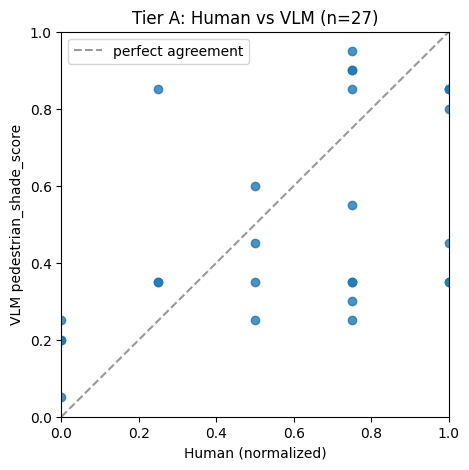

In [2]:
tier_a = filter_real_images(eval_frame)
vlm_metrics = compute_method_metrics(tier_a, "pedestrian_shade_score")
print("Tier A (real images only):", vlm_metrics)

if tier_a.empty:
    print("No labeled real images with scores — complete human_labels.csv and run score_eval.")
else:
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(tier_a["human_norm"], tier_a["pedestrian_shade_score"], alpha=0.8)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="perfect agreement")
    ax.set_xlabel("Human (normalized)")
    ax.set_ylabel("VLM pedestrian_shade_score")
    ax.set_title(f"Tier A: Human vs VLM (n={len(tier_a)})")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
    plt.show()


## Tier B — Run stability

Same image + prompt scored **3 times** on a 10-image subset from `sample/`.


In [3]:
if run_variance.empty:
    print("No run variance data — run: uv run python eval/collect_run_variance.py")
else:
    summary = stability_summary(run_stats, run_variance)
    print("Stability summary:", summary)
    display(run_stats.sort_values("score_std", ascending=False))

    high_var = run_stats[run_stats["score_range"] > HIGH_VARIANCE_RANGE]
    if not high_var.empty:
        print(f"High-variance images (range > {HIGH_VARIANCE_RANGE}):")
        display(high_var)


Stability summary: {'n_images': 10, 'median_std': 0.0, 'max_range': 0.14999999999999997, 'pct_high_variance': 0.0, 'test_retest_spearman': 0.9714679613862723}


,uuid,score_mean,score_std,score_range,n_runs
1,17d50c04-4584-4424-933c-d56b52db6f40,0.250000,0.070711,0.15,3
3,282017c7-476a-41db-8df3-800b7487ea32,0.533333,0.023570,0.05,3
9,cabdd3be-7e50-444f-abc2-ad0e5bc621fb,0.866667,0.023570,0.05,3
0,144424e9-857e-440b-a4bc-fd979a4be00d,0.600000,0.000000,0.00,3
4,2b6f5142-e669-4aba-84f5-c04b4eac11b0,0.850000,0.000000,0.00,3
2,1e7a40c0-41a9-470a-a1bb-70fab7c33184,0.350000,0.000000,0.00,3
5,2bf39502-b160-452a-86d1-eaae4420cafd,0.050000,0.000000,0.00,3
6,4801a5d5-a895-4dc5-a8a0-bb78d3e22728,0.350000,0.000000,0.00,3
7,49d87853-5f2e-4868-a1c3-b262c8fe1190,0.850000,0.000000,0.00,3
8,508f39d3-7f3c-493f-a9e1-c115e7687393,0.850000,0.000000,0.00,3


## Tier C — Mismatch analysis

Bar chart of **all** labeled images by `scene_category`, coloured by `source` (real vs synthetic). The dashed line marks the mismatch threshold. The gallery below shows all images, sorted from most to least deviation.


Mismatches: 11 (threshold=0.25)


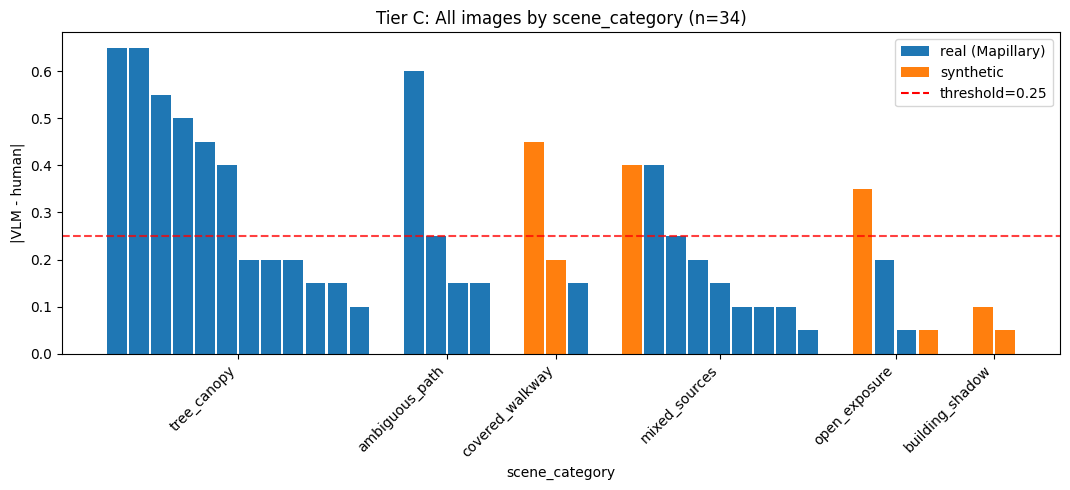

,scene_category,count
4,tree_canopy,6
2,mixed_sources,2
0,ambiguous_path,1
1,covered_walkway,1
3,open_exposure,1


In [4]:
mismatches = flag_mismatches(eval_frame, threshold=MISMATCH_THRESHOLD)
print(f"Mismatches: {len(mismatches)} (threshold={MISMATCH_THRESHOLD})")

if not eval_frame.empty:
    source_colors = {"mapillary": "C0", "synthetic": "C1"}
    source_labels = {"mapillary": "real (Mapillary)", "synthetic": "synthetic"}

    cat_order = (
        eval_frame.groupby("scene_category")["err_vlm"]
        .max()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    fig, ax = plt.subplots(figsize=(max(8, len(cat_order) * 1.8), 5))
    category_centers = []
    category_names = []
    current_x = 0.0
    bar_width = 0.55
    category_gap = 0.8

    for cat in cat_order:
        group = (
            eval_frame[eval_frame["scene_category"] == cat]
            .sort_values("err_vlm", ascending=False)
        )
        n = len(group)
        if n == 0:
            continue
        offsets = [current_x + i * bar_width for i in range(n)]
        colors = [source_colors.get(src, "C2") for src in group["source"]]
        ax.bar(offsets, group["err_vlm"], width=bar_width * 0.9, color=colors)
        category_centers.append(current_x + (n - 1) * bar_width / 2)
        category_names.append(cat)
        current_x += n * bar_width + category_gap

    ax.axhline(
        MISMATCH_THRESHOLD,
        color="red",
        linestyle="--",
        alpha=0.75,
        label=f"threshold={MISMATCH_THRESHOLD}",
    )
    ax.set_xticks(category_centers)
    ax.set_xticklabels(category_names, rotation=45, ha="right")
    ax.set_ylabel("|VLM - human|")
    ax.set_xlabel("scene_category")
    ax.set_title(f"Tier C: All images by scene_category (n={len(eval_frame)})")

    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D

    legend_handles = [
        Patch(facecolor=source_colors[src], label=source_labels[src])
        for src in source_colors
        if src in set(eval_frame["source"])
    ]
    legend_handles.append(
        Line2D(
            [0],
            [0],
            color="red",
            linestyle="--",
            label=f"threshold={MISMATCH_THRESHOLD}",
        )
    )
    ax.legend(handles=legend_handles, loc="upper right")
    plt.tight_layout()
    plt.show()

if not mismatches.empty:
    display(summarize_mismatches_by_scene_category(mismatches))
else:
    print("No mismatches at current threshold — consider lowering MISMATCH_THRESHOLD.")


In [ ]:
from PIL import Image


def show_mismatch_card(row):
    image_path = resolve_image_path(row["uuid"])
    stability_line = ""
    if "run_std" in row and pd.notna(row.get("run_std")):
        stability_line = (
            f"<p>Run stability: std={row['run_std']:.2f} · range={row['run_range']:.2f}</p>"
        )
    hour = row.get("hour", "—")
    sidewalk = row.get("sidewalk_pct", float("nan"))
    sidewalk_text = f"{sidewalk:.1%}" if pd.notna(sidewalk) else "—"
    display(
        HTML(
            f"<h4>{row['scene_category']} · {row.get('source', '—')}</h4>"
            f"<p>"
            f"human={row['shade_1to5']} (norm {row['human_norm']:.2f}) · "
            f"VLM={row['pedestrian_shade_score']:.2f} (err {row['err_vlm']:.2f})"
            f"</p>"
            f"<p>hour={hour} · sidewalk_pct={sidewalk_text} · heading={row.get('heading', '—')}°</p>"
            f"{stability_line}"
            f"<p><i>{row.get('reasoning', '')}</i></p>"
            f"<p><b>Notes:</b> {row.get('notes', '') or '—'}</p>"
        )
    )
    if image_path and image_path.exists():
        display(Image.open(image_path).convert("RGB"))
    else:
        display(HTML(f"<p><i>Missing image for {row['uuid']}</i></p>"))
    display(HTML("<hr>"))


if eval_frame.empty:
    print("No images to show.")
else:
    ranked = eval_frame.sort_values("err_vlm", ascending=False).reset_index(drop=True)
    display(
        HTML(
            f"<h3>Image gallery (sorted by deviation, "
            f"threshold={MISMATCH_THRESHOLD})</h3>"
        )
    )
    for rank, (_, row) in enumerate(ranked.iterrows(), start=1):
        flag = " · mismatch" if row["err_vlm"] > MISMATCH_THRESHOLD else ""
        display(HTML(f"<p><b>#{rank}</b> · err={row['err_vlm']:.2f}{flag}</p>"))
        show_mismatch_card(row)


## Takeaways

- Tier A (real only): VLM Spearman ρ = 0.527, MAE = 0.263 (n=27)
- Tier B: median run std = 0.00, max range = 0.15, test-retest Spearman = 0.97, 0% high-variance images
- Tier C: 11 mismatches at threshold 0.25 (tree_canopy 6, mixed_sources 2, ambiguous_path 1, covered_walkway 1, open_exposure 1)
- **By scene type:** `tree_canopy` performed worst — most mismatches and the hardest category to label consistently. `ambiguous_path` and `mixed_sources` were surprisingly good despite sounding difficult. `open_exposure` was generally accurate, which matters most for flagging truly exposed routes.
- **Label uncertainty:** Roughly half of Tier C errors are on images the rater was also unsure about; poor image quality or ambiguous framing may be driving disagreement as much as model failure.
- **Covered walkways:** Confusing for the human rater — linkways/overhangs technically provide full shade, but visible sun patches in frame led the rater to score it half. The VLM scored it as high shade and could be more accurate.
- Limitation: single rater, static snapshots, N≈30 real images on afternoon sidewalks and N=7 synthetic images that could be further tuned.
